In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content (1).jpg


In [21]:
def load_image(path, max_size=400):
    image = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize(max_size),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

In [23]:
content = load_image("content.jpg")
style = load_image("style3.jpg")

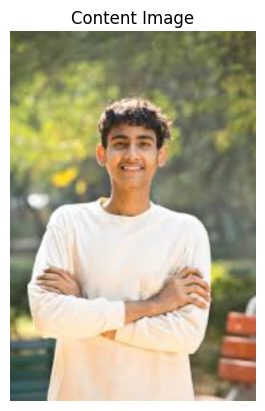

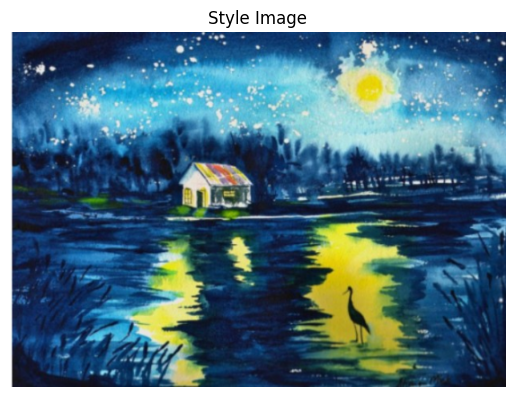

In [25]:
def imshow(tensor, title=None):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content, "Content Image")
imshow(style, "Style Image")

In [27]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

In [28]:
content_layer = '21'  # conv4_2
style_layers = ['0', '5', '10', '19', '28']

In [29]:
def get_features(image, model):
    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name == content_layer:
            features['content'] = x
        if name in style_layers:
            features[name] = x

    return features

In [30]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

In [31]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [32]:
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [33]:
def content_loss(target, content):
    return torch.mean((target - content)**2)

In [34]:
def style_loss(target, style_gram):
    target_gram = gram_matrix(target)
    return torch.mean((target_gram - style_gram)**2)

In [35]:
target = content.clone().requires_grad_(True).to(device)

In [36]:
optimizer = optim.Adam([target], lr=0.003)

In [37]:
steps = 1500
content_weight = 1e4
style_weight = 50

for i in range(steps):

    target_features = get_features(target, vgg)

    # Content loss
    c_loss = content_loss(target_features['content'],
                          content_features['content'])

    # Style loss
    s_loss = 0
    for layer in style_layers:
        target_feature = target_features[layer]
        style_gram = style_grams[layer]
        s_loss += style_loss(target_feature, style_gram)

    total_loss = content_weight * c_loss + style_weight * s_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    with torch.no_grad():
      target.clamp_(0, 1)

    if i % 400 == 0:
        print(f"Step {i}, Total Loss: {total_loss.item()}")

Step 0, Total Loss: 4280457728.0
Step 400, Total Loss: 126333536.0
Step 800, Total Loss: 98924520.0
Step 1200, Total Loss: 86254680.0


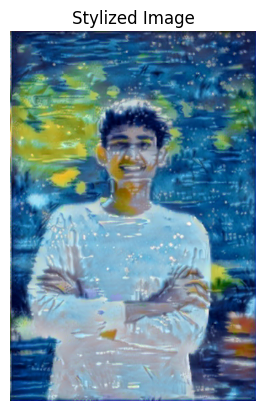

In [38]:
imshow(target, "Stylized Image")